In [7]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from arch.univariate import ARX
from scipy.stats import norm,kurtosis, skew, jarque_bera
from sklearn.mixture import GaussianMixture
from scipy.optimize import minimize

### Import data

In [2]:
path = os.path.abspath('E:/RA/Geert/task1.py')
dir_path = os.path.dirname(path)
os.chdir(dir_path)
excel_file = pd.ExcelFile('Aggregate_CPI_inflation_20230513.xls')
sheet_quarter = excel_file.sheet_names[0]
sheet_month = excel_file.sheet_names[1]
#quarterly and monthly aggregate CPI data (deseasonalized). The full sample is 1947-2022
data_quarter = excel_file.parse(sheet_quarter, skiprows=2)
data_month = excel_file.parse(sheet_month, skiprows=2)
data_quarter.index = pd.to_datetime(data_quarter['Year'].astype(str) + '-Q' + data_quarter['Quarter'].astype(str))
data_month.index = pd.to_datetime(data_month[['Year', 'Month']].assign(day=1))
data_quarter.columns = ['Year', 'Quarter', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
data_month.columns = ['Year', 'Month', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
sample_data = data_quarter[data_quarter['Year']>1969]

In [4]:
sample_data['Inflation_lag_1'] =  sample_data['Inflation'].shift(1)
sample_data['Inflation_lag_2'] =  sample_data['Inflation'].shift(2)
sample_data['Forecasted_inflation_lag_1'] =  sample_data['Forecasted inflation'].shift(1)
sample_data = sample_data.dropna()

# Summary Statistics

## Model Selection

## Mean Model

**I report JB tests and mixture of normal parameters based on  scaled residuals.**


1. Estimated a GJR-GARCH(2,1) with normal distribution
2. Estimated Mixture of normals using Scaled residuals of that GARCH with constraints(zero mean and unit variance)
3. Reported estimated parameters, plot residuals histogram and estimated mixture of normals distribution

$
\pi (t) =  fc(t-1) + \epsilon (t)
$

GJR-GARCH(2,1) with normal error distribution
Scaled residual excess Kurtosis: 2.666126329390446
Scaled residual Skewness: 0.1513462614180955
Jarque-Bera Test p-value: 2.8199664825478976e-14 Jarque-Bera Test Statistic: 62.398720519632555
Estimate Mixture of normal using residuals from above GARCH model


C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_856/2764013632.py:18: RuntimeWarning: invalid value encountered in double_scalars
  lls =-np.log(volatility) +   np.log(p1 * norm.pdf(z, u1, sigma_1_2**0.5) + p2 * norm.pdf(z, u2, sigma_2_2**0.5))


Mixture of 2 normals parameters: 
Probabilities:  [0.10060357035206066, 0.8993964296479393]
Means:  [-0.7945164846585182, 0.0888720395426781]
Variances:  [3.926270269184304, 0.6638951786523866]
Whether converge: True .   Optimization terminated successfully


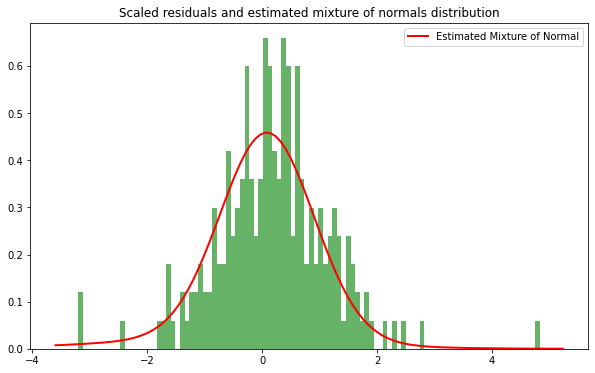

In [95]:
normalResults(Y = sample_data['Inflation shock'],mean='Zero')

$
\pi (t) = c +\rho \pi (t-1)   + \phi fc(t-1) + \epsilon (t)
$

GJR-GARCH(2,1) with normal error distribution
Scaled residual excess Kurtosis: 2.840913314661994
Scaled residual Skewness: 0.19441907548572565
Jarque-Bera Test p-value: 4.440892098500626e-16 Jarque-Bera Test Statistic: 70.9146082832692
Estimate Mixture of normal using residuals from above GARCH model
Mixture of 2 normals parameters: 
Probabilities:  [0.08006771302440947, 0.9199322869755905]
Means:  [-0.2055183978374648, 0.017887607960131502]
Variances:  [4.512543325474329, 0.6939326062637806]
Whether converge: True .   Optimization terminated successfully


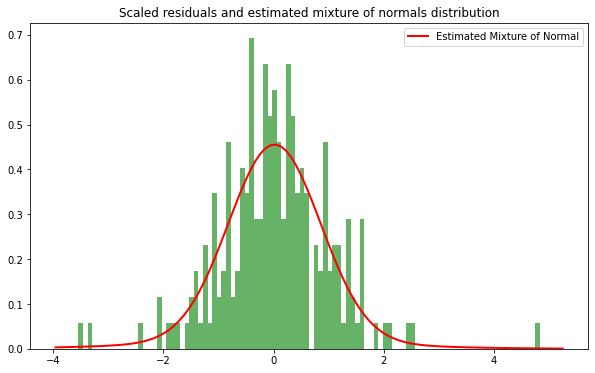

In [96]:
normalResults(Y = sample_data['Inflation'],X=sample_data['Forecasted inflation'],mean='ARX',lags=[1])

$
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi fc(t-1) + \epsilon (t)
$

GJR-GARCH(2,1) with normal error distribution
Scaled residual excess Kurtosis: 2.8938955993187374
Scaled residual Skewness: 0.18681607331694516
Jarque-Bera Test p-value: 1.1102230246251565e-16 Jarque-Bera Test Statistic: 73.08049751981041
Estimate Mixture of normal using residuals from above GARCH model
Mixture of 2 normals parameters: 
Probabilities:  [0.08114153281157167, 0.9188584671884283]
Means:  [-0.20335695366139125, 0.0179578199659701]
Variances:  [4.525076366837366, 0.6883605112143582]
Whether converge: True .   Optimization terminated successfully


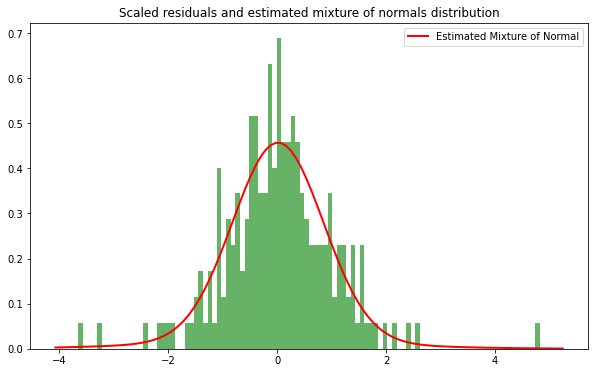

In [98]:
normalResults(Y = sample_data['Inflation'],X=sample_data['Forecasted inflation'],mean='ARX',lags=[1,2])

$
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi_1 fc(t-1) + \phi_2 fc(t-2) + \epsilon (t)
$

GJR-GARCH(2,1) with normal error distribution
Scaled residual excess Kurtosis: 2.8915055877769893
Scaled residual Skewness: 0.18207979875669358
Jarque-Bera Test p-value: 1.1102230246251565e-16 Jarque-Bera Test Statistic: 72.90182733254058
Estimate Mixture of normal using residuals from above GARCH model
Mixture of 2 normals parameters: 
Probabilities:  [0.08270805782306773, 0.9172919421769323]
Means:  [-0.21042287159441794, 0.018972876824606577]
Variances:  [4.480774373997904, 0.6857619205019966]
Whether converge: True .   Optimization terminated successfully


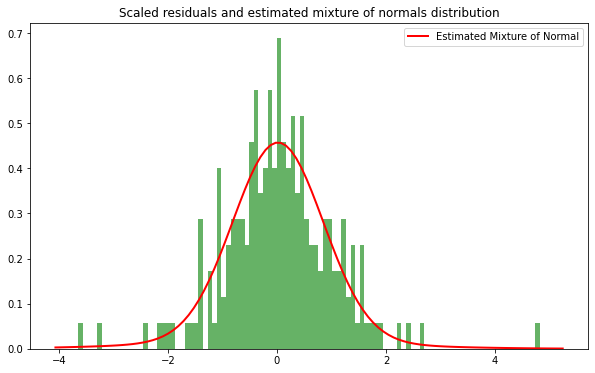

In [99]:
normalResults(Y = sample_data['Inflation'],X=sample_data[['Forecasted inflation','Forecasted_inflation_lag_1']],mean='ARX',lags=[1,2])

Comments:

1. MLE converges in each case, and parameters do not go to boundary.
2. Estimation results seem consistent. In each mean model situation, mixture of normal parameters are similar: one normal with low weight, negative mean and high volatility; one normal with high weight, positive mean and low volatility.
3. When estimating SPARCH, we expect similar results.(In fact they are close.)
4. In file SPACH.html, I report SPARCH parameters of volatiliy process and mixture of normals which are estimated together.

In [94]:
def print_param(params):
    """print distributional parameters"""
    p1,u1,sigma_1_2 = params
    p2 = 1- p1
    u2 = p1/(p1-1) *u1
    sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
    print('Mixture of 2 normals parameters: ')
    print("Probabilities: ", [p1,p2])
    print("Means: ", [u1,u2])
    print("Variances: ", [sigma_1_2,sigma_2_2])
def MofN_estimation(errors,volatility):
    z = errors / volatility
    def MofN_llf(params):
        p1,u1,sigma_1_2 = params
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        lls =-np.log(volatility) +   np.log(p1 * norm.pdf(z, u1, sigma_1_2**0.5) + p2 * norm.pdf(z, u2, sigma_2_2**0.5))
        return -np.sum(lls)
    init_params = [0.3, 0.1,1]
    # Bound constraints, sigma > 0, 0 < p1 < 1
    bnds = ((1e-5, 1 - 1e-5), (None, None), (1e-5, None))
    # Constraints 
    constraints = {'type': 'ineq',
                    'fun': lambda x: np.array([ 1 - 1e-5 - x[0] * (x[1]**2 + x[2]) - (1 - x[0]) * (x[0] * x[1] / (1 - x[0]))**2])} 
    res = minimize(MofN_llf, init_params, bounds=bnds, constraints=constraints)
    print_param(res.x)
    print('Whether converge:',res.success,'.  ', res.message)
    return res.x

def normalResults(Y,X=None,mean='Zero',lags=None,cov = 'robust'):
    print('GJR-GARCH(2,1) with normal error distribution')
    options = {'maxiter': 1000}
    gjr = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=2, o=2,q=1,lags=lags).fit(disp='off',cov_type=cov,options=options)
    residuals = (gjr.resid/gjr.conditional_volatility).dropna()
    # Calculate kurtosis and skewness
    residual_kurtosis = kurtosis(residuals, fisher=True)
    residual_skewness = skew(residuals)
    # Perform normality test (Jarque-Bera)
    test_statistic, p_value = jarque_bera(residuals)
    print("Scaled residual excess Kurtosis:", residual_kurtosis)
    print("Scaled residual Skewness:", residual_skewness)
    print("Jarque-Bera Test p-value:", p_value,"Jarque-Bera Test Statistic:", test_statistic)
    
    print('Estimate Mixture of normal using residuals from above GARCH model')
    p1,u1,sigma_1_2 = MofN_estimation(gjr.resid,gjr.conditional_volatility)
    plt.figure(figsize=(10,6))
    plt.hist(gjr.resid/gjr.conditional_volatility, bins=100, density=True, alpha=0.6, color='g')
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p2 = 1- p1
    u2 = p1/(p1-1) *u1
    sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)  
    p = p1 * norm.pdf(x, u1, sigma_1_2**0.5) + \
        p2 * norm.pdf(x, u2, sigma_2_2**0.5)
    plt.plot(x, p,  linewidth=2,label = 'Estimated Mixture of Normal',color='r')
    plt.title('Scaled residuals and estimated mixture of normals distribution')
    plt.legend ()
    plt.show()